# Fase 3b: Arquitetura de Stacking Multi-Target com Features Externas

- Repete a arquitetura da Fase 3a com o dataset enriquecido com features externas.
- O objetivo é comparar os resultados com a Fase 3a e avaliar o impacto das features externas nos três targets e na camada de cenários.

## Diferenças face à Fase 3a

| Componente | Fase 3a | Fase 3b |
|---|---|---|
| Dataset | `generated_dataset.csv` (29 cols) | `generated_dataset_ext.csv` (47 cols) |
| Features externas | nenhuma | jet fuel · carbono · load factor · feriados · clima · price factor |
| Cenários | só Rolling_DEP_DELAY (efeito nulo) | jet fuel · clima · carbono (variação real) |

## Arquitetura (igual à Fase 3a)

| Target | Modelo 1 | Modelo 2 | Modelo 3 |
|---|---|---|---|
| Custo | Regressão Linear | Random Forest | XGBoost |
| Duração | Random Forest | LinearSVR | XGBoost |
| CO₂ | Modelo físico ICAO | Random Forest | XGBoost |

## 1. Setup e Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


## 2. Carregamento e Preparação

In [2]:
PATH = 'generated_dataset_ext.csv'

df = pd.read_csv(PATH, low_memory=False)
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')

# Corrigir nulls no jet fuel (dias sem cotação antes do primeiro registo disponível)
df['jet_fuel_price_usd'] = df['jet_fuel_price_usd'].bfill().ffill()

df = df.sort_values('FL_DATE').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Período: {df["FL_DATE"].min().date()} -> {df["FL_DATE"].max().date()}')
print(f'Nulls totais: {df.isnull().sum().sum()}')
print()

# Confirmar features externas presentes
ext_features = ['jet_fuel_price_usd','carbon_price_usd','load_factor_prev_month','is_holiday',
                'hist_route_price','temp_origin_c','temp_dest_c','precip_origin_mm',
                'precip_dest_mm','wind_origin_kmh','wind_dest_kmh',
                'extreme_temp_origin','extreme_temp_dest','heavy_rain_origin',
                'heavy_rain_dest','strong_wind_origin','strong_wind_dest']

print('Features externas disponíveis:')
for f in ext_features:
    status = 'Presente' if f in df.columns else 'Ausente'
    if f in df.columns:
        print(f'  {status} {f:<28} mean={df[f].mean():.3f} | nulls={df[f].isnull().sum()}')
    else:
        print(f'  {status} {f}')

Shape: (195950, 46)
Período: 2023-01-01 -> 2023-08-31
Nulls totais: 0

Features externas disponíveis:
  Presente jet_fuel_price_usd           mean=2.655 | nulls=0
  Presente carbon_price_usd             mean=30.691 | nulls=0
  Presente load_factor_prev_month       mean=0.784 | nulls=0
  Presente is_holiday                   mean=0.028 | nulls=0
  Presente hist_route_price             mean=186.289 | nulls=0
  Presente temp_origin_c                mean=17.795 | nulls=0
  Presente temp_dest_c                  mean=17.776 | nulls=0
  Presente precip_origin_mm             mean=3.120 | nulls=0
  Presente precip_dest_mm               mean=3.122 | nulls=0
  Presente wind_origin_kmh              mean=19.944 | nulls=0
  Presente wind_dest_kmh                mean=19.936 | nulls=0
  Presente extreme_temp_origin          mean=0.004 | nulls=0
  Presente extreme_temp_dest            mean=0.004 | nulls=0
  Presente heavy_rain_origin            mean=0.025 | nulls=0
  Presente heavy_rain_dest           

## 3. Features e Targets

In [3]:
TARGET_COST     = 'COST_PRED_USD'
TARGET_DURATION = 'DURATION_REAL_MIN'
TARGET_CO2      = 'CO2_kg'
TARGETS = [TARGET_COST, TARGET_DURATION, TARGET_CO2]

# Features base — comuns a todos os targets
FEATURES_CAT = ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'Season']
FEATURES_NUM_BASE = [
    'haversine_distance', 'route_nonlinearity',
    'Month', 'DayofWeek', 'DayofMonth', 'Quarter',
    'IsWeekend', 'IsNightFlight',
    'CRS_ELAPSED_TIME', 'DEP_HOUR', 'Rolling_DEP_DELAY',
    'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON',
]
BASE = FEATURES_CAT + FEATURES_NUM_BASE

# Candidatas por target - definidas pela lógica do domínio
# Custo: contexto de mercado, combustível, ocupação, histórico de preço
CANDIDATES_COST = BASE + [
    'jet_fuel_price_usd',      # custo operacional das companhias
    'carbon_price_usd',        # contexto de política climática
    'load_factor_prev_month',  # pressão de procura (mês anterior)
    'hist_route_price',        # histórico de preço da rota
    'is_holiday',              # padrão de procura em feriados
]

# Duração: condições meteorológicas e operacionais
CANDIDATES_DUR = BASE + [
    'load_factor_prev_month',  # pressão de procura pode afetar routing
    'is_holiday',              # padrão de tráfego em feriados
    'temp_origin_c',           # temperatura na origem
    'temp_dest_c',             # temperatura no destino
    'precip_origin_mm',        # precipitação na origem
    'precip_dest_mm',          # precipitação no destino
    'wind_origin_kmh',         # vento na origem
    'wind_dest_kmh',           # vento no destino
    'extreme_temp_origin',     # temperatura operacionalmente limitante
    'extreme_temp_dest',
    'heavy_rain_origin',       # chuva intensa (>25mm)
    'heavy_rain_dest',
    'strong_wind_origin',      # vento forte (>50km/h)
    'strong_wind_dest',
]

# CO₂: apenas features base - sem externas
# - carbon_price_usd: política económica, não altera emissões físicas
# - load_factor_prev_month: faz sentido para CO₂/pax, não CO₂ total por voo
# - temperatura/clima: target foi construído por fórmula sem temperatura
# O sinal útil está nas features base: AIRLINE_CODE (eficiência por companhia) e haversine_distance (driver principal da fórmula ICAO)
CANDIDATES_CO2 = BASE

# Lista de todas as features externas (para referência e visualização)
FEATURES_EXT = [
    'jet_fuel_price_usd', 'carbon_price_usd', 'load_factor_prev_month',
    'hist_route_price', 'is_holiday',
    'temp_origin_c', 'temp_dest_c', 'precip_origin_mm', 'precip_dest_mm',
    'wind_origin_kmh', 'wind_dest_kmh',
    'extreme_temp_origin', 'extreme_temp_dest',
    'heavy_rain_origin', 'heavy_rain_dest',
    'strong_wind_origin', 'strong_wind_dest',
]

# União de todas as candidatas (para pré-processamento e encoding)
ALL_CANDIDATES = list(dict.fromkeys(CANDIDATES_COST + CANDIDATES_DUR + CANDIDATES_CO2))
available = [f for f in ALL_CANDIDATES if f in df.columns]

candidates_per_target = {
    TARGET_COST:     [f for f in CANDIDATES_COST if f in df.columns],
    TARGET_DURATION: [f for f in CANDIDATES_DUR  if f in df.columns],
    TARGET_CO2:      [f for f in CANDIDATES_CO2  if f in df.columns],
}

print(f'Candidatas por target:')
for t, label in [(TARGET_COST,'Custo'),(TARGET_DURATION,'Duração'),(TARGET_CO2,'CO₂')]:
    ext = [f for f in candidates_per_target[t] if f in FEATURES_EXT]
    print(f'  {label:<10}: {len(candidates_per_target[t])} total | externas: {ext}')

print()
for t in TARGETS:
    assert t not in available, f'LEAKAGE: {t} nas candidatas'
print('Verificação de leakage: OK')

Candidatas por target:
  Custo     : 24 total | externas: ['jet_fuel_price_usd', 'carbon_price_usd', 'load_factor_prev_month', 'hist_route_price', 'is_holiday']
  Duração   : 33 total | externas: ['load_factor_prev_month', 'is_holiday', 'temp_origin_c', 'temp_dest_c', 'precip_origin_mm', 'precip_dest_mm', 'wind_origin_kmh', 'wind_dest_kmh', 'extreme_temp_origin', 'extreme_temp_dest', 'heavy_rain_origin', 'heavy_rain_dest', 'strong_wind_origin', 'strong_wind_dest']
  CO₂       : 19 total | externas: []

Verificação de leakage: OK


## 4. Pré-processamento

In [4]:
df_model = df[available + TARGETS].copy()

le_dict = {}
for col in FEATURES_CAT:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le

for col in df_model.columns:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].median(), inplace=True)

df_model['Month'] = df['Month'].values

print(f'Dataset de modelação: {df_model.shape}')
print(f'Nulls: {df_model.isnull().sum().sum()}')
print()
print('Targets:')
for t in TARGETS:
    s = df_model[t]
    print(f'  {t:<25} mean={s.mean():.1f} | std={s.std():.1f}')

Dataset de modelação: (195950, 39)
Nulls: 0

Targets:
  COST_PRED_USD             mean=187.9 | std=70.2
  DURATION_REAL_MIN         mean=147.1 | std=73.0
  CO2_kg                    mean=21519.6 | std=13524.4


## 5. Seleção de Features (Pearson 0.03 + LASSO + RF, ≥2 votos)

In [5]:
def select_features(df_m, feature_cols, target_col, pearson_thr=0.03, top_n_rf=12):
    X = df_m[feature_cols]
    y = df_m[target_col]

    pearson = X.corrwith(y).abs()
    pearson_sel = set(pearson[pearson >= pearson_thr].index)

    sc = StandardScaler()
    X_sc = sc.fit_transform(X)
    lasso = LassoCV(cv=5, max_iter=5000, random_state=SEED, n_jobs=-1)
    lasso.fit(X_sc, y)
    coef = pd.Series(np.abs(lasso.coef_), index=feature_cols)
    lasso_sel = set(coef[coef > 0].index)

    rf_s = RandomForestRegressor(n_estimators=100, max_depth=8,
                                  random_state=SEED, n_jobs=-1)
    rf_s.fit(X, y)
    imp = pd.Series(rf_s.feature_importances_, index=feature_cols)
    rf_sel = set(imp.nlargest(top_n_rf).index)

    summary = pd.DataFrame({
        'feature': feature_cols,
        'pearson': [f in pearson_sel for f in feature_cols],
        'lasso':   [f in lasso_sel   for f in feature_cols],
        'rf':      [f in rf_sel      for f in feature_cols],
    })
    summary['votes']    = summary[['pearson','lasso','rf']].sum(axis=1)
    summary['selected'] = summary['votes'] >= 2
    selected = summary[summary['selected']]['feature'].tolist()
    return summary, selected, pearson

print('A executar seleção de features por target (candidatas específicas por domínio)...')
print()

feature_sets = {}
summaries    = {}

for target, label in [
    (TARGET_COST,     'Custo'),
    (TARGET_DURATION, 'Duração'),
    (TARGET_CO2,      'CO₂'),
]:
    print(f'--- {label} ---')
    cands = candidates_per_target[target]
    s, selected, _ = select_features(df_model, cands, target)
    feature_sets[target] = selected
    summaries[target]    = s
    ext_selected = [f for f in selected if f in FEATURES_EXT]
    print(f'  Candidatas: {len(cands)} | Selecionadas: {len(selected)}')
    print(f'  Features externas selecionadas: {ext_selected}')
    print()

A executar seleção de features por target (candidatas específicas por domínio)...

--- Custo ---
  Candidatas: 24 | Selecionadas: 12
  Features externas selecionadas: ['load_factor_prev_month', 'hist_route_price']

--- Duração ---
  Candidatas: 33 | Selecionadas: 17
  Features externas selecionadas: ['load_factor_prev_month', 'temp_origin_c', 'temp_dest_c', 'precip_origin_mm', 'precip_dest_mm', 'wind_origin_kmh', 'wind_dest_kmh']

--- CO₂ ---
  Candidatas: 19 | Selecionadas: 10
  Features externas selecionadas: []



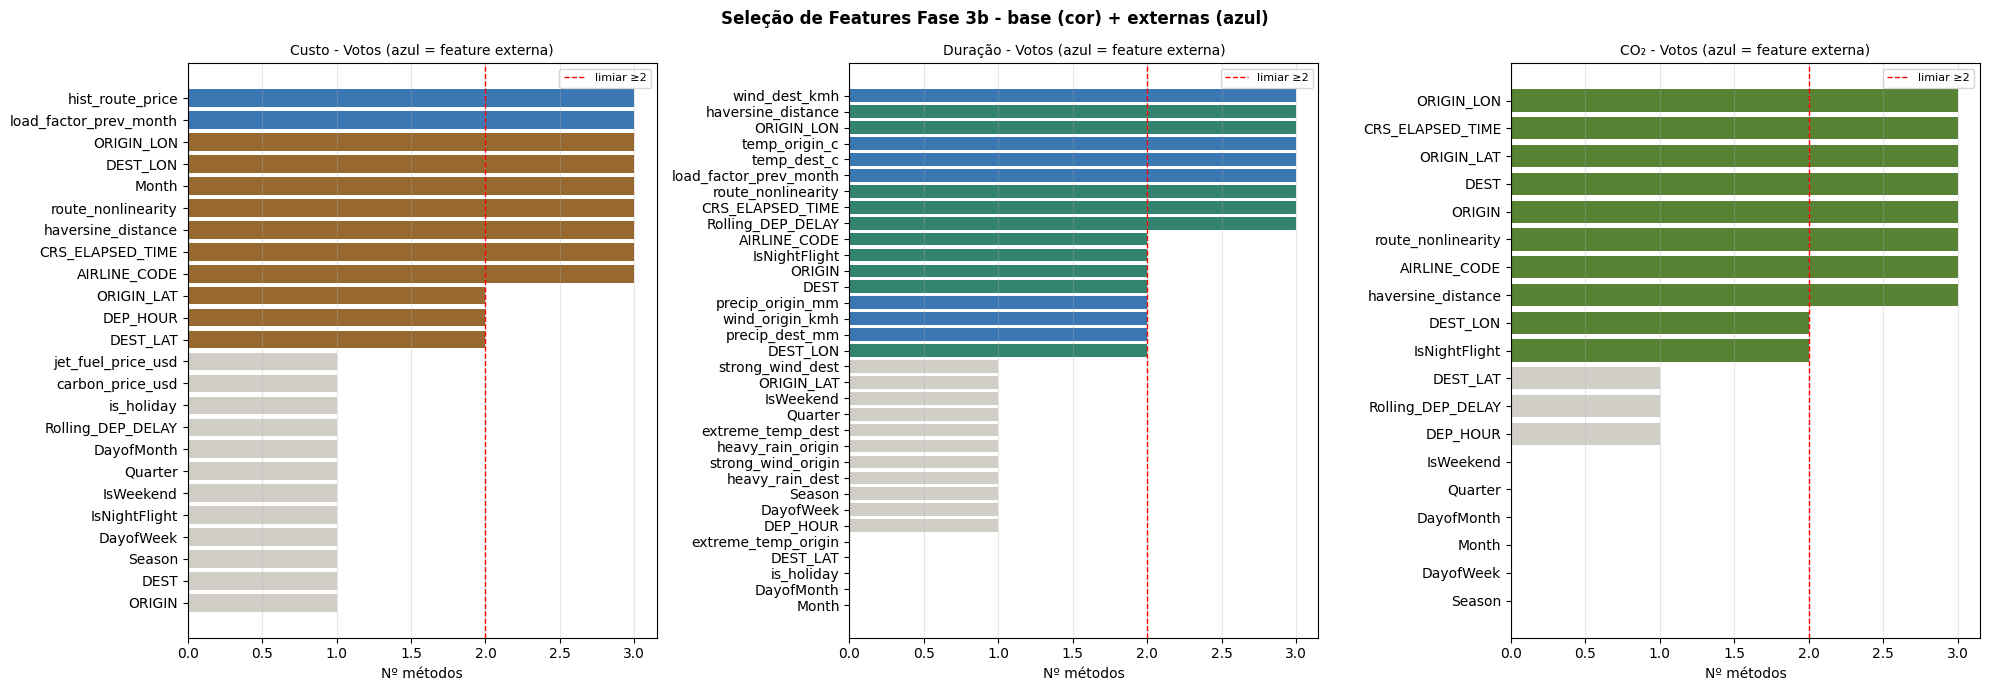

In [6]:
# Visualização - votos por target (destaque nas features externas)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
hex_t = ['#854F0B', '#0F6E56', '#3B6D11']

for ax, target, title, color in zip(axes,
    [TARGET_COST, TARGET_DURATION, TARGET_CO2],
    ['Custo', 'Duração', 'CO₂'], hex_t):

    s = summaries[target].sort_values('votes', ascending=True)
    bar_colors = []
    for _, row in s.iterrows():
        if row['votes'] >= 2 and row['feature'] in FEATURES_EXT:
            bar_colors.append('#185FA5')   # externa selecionada - azul
        elif row['votes'] >= 2:
            bar_colors.append(color)         # base selecionada - cor do target
        else:
            bar_colors.append('#C8C6BE')   # não selecionada - cinza

    ax.barh(s['feature'], s['votes'], color=bar_colors, alpha=0.85)
    ax.axvline(2, color='red', linestyle='--', lw=1, label='limiar ≥2')
    ax.set_title(f'{title} - Votos (azul = feature externa)', fontsize=10)
    ax.set_xlabel('Nº métodos')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Seleção de Features Fase 3b - base (cor) + externas (azul)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fase3b_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Walk-Forward 5 Folds e Funções Auxiliares

In [7]:
FOLDS = [
    {'train_months': [1],                 'test_months': [2]},
    {'train_months': [1,2],               'test_months': [3]},
    {'train_months': [1,2,3],             'test_months': [4,5]},
    {'train_months': [1,2,3,4,5],         'test_months': [6,7]},
    {'train_months': [1,2,3,4,5,6,7],     'test_months': [8]},
]

def evaluate(name, y_true, y_pred):
    return {'model': name,
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae':  mean_absolute_error(y_true, y_pred),
            'r2':   r2_score(y_true, y_pred) * 100}

def fmt(d):
    return f"RMSE={d['rmse']:.3f} | MAE={d['mae']:.3f} | R²={d['r2']:.3f}%"

def walk_forward_oof(models_dict, df_m, y_series, feature_cols, folds, scale=False):
    n = len(df_m)
    oof_matrix = np.zeros((n, len(models_dict)))
    oof_mask   = np.zeros(n, dtype=bool)

    for fold in folds:
        tr_mask = df_m['Month'].isin(fold['train_months']).values
        te_mask = df_m['Month'].isin(fold['test_months']).values

        X_tr_raw = df_m.loc[tr_mask, feature_cols].values
        X_te_raw = df_m.loc[te_mask, feature_cols].values
        y_tr     = y_series.values[tr_mask]

        if scale:
            sc   = StandardScaler()
            X_tr = sc.fit_transform(X_tr_raw)
            X_te = sc.transform(X_te_raw)
        else:
            X_tr, X_te = X_tr_raw, X_te_raw

        for j, (name, model) in enumerate(models_dict.items()):
            model.fit(X_tr, y_tr)
            oof_matrix[np.where(te_mask)[0], j] = model.predict(X_te)

        oof_mask[te_mask] = True

    return oof_matrix, oof_mask

print('Walk-forward folds e funções auxiliares prontos.')

Walk-forward folds e funções auxiliares prontos.


## 7. Nível 0 - Modelos Base

### 7.1 Custo (LR + RF + XGBoost)

In [8]:
import time

X = df_model[available].copy()
# garantir que Month está presente para os folds (já está em available)
if 'Month' not in X.columns:
    X['Month'] = df_model['Month'].values

feats_cost = feature_sets[TARGET_COST]  # já definido na seleção

y_cost = df_model[TARGET_COST]
feats_cost = feature_sets[TARGET_COST]

models_cost = {
    'LR_cost':  LinearRegression(),
    'RF_cost':  RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'XGB_cost': xgb.XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0),
}

print(f'Features custo ({len(feats_cost)}): {feats_cost}')
t0 = time.time()
oof_cost, mask_cost = walk_forward_oof(
    models_cost, X, y_cost, feats_cost, FOLDS, scale=True)
print(f'Tempo: {time.time()-t0:.1f}s')

results_cost_l0 = []
y_true_cost = y_cost.values[mask_cost]
for j, name in enumerate(models_cost):
    r = evaluate(name, y_true_cost, oof_cost[mask_cost, j])
    results_cost_l0.append(r)
    print(f'{name:<12} {fmt(r)}')

Features custo (12): ['AIRLINE_CODE', 'haversine_distance', 'route_nonlinearity', 'Month', 'CRS_ELAPSED_TIME', 'DEP_HOUR', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON', 'load_factor_prev_month', 'hist_route_price']
Tempo: 124.9s
LR_cost      RMSE=44.581 | MAE=34.845 | R²=59.632%
RF_cost      RMSE=41.465 | MAE=32.339 | R²=65.077%
XGB_cost     RMSE=40.357 | MAE=31.682 | R²=66.919%


### 7.2 Duração (RF + LinearSVR + XGBoost)

In [9]:
y_dur = df_model[TARGET_DURATION]
feats_dur = feature_sets[TARGET_DURATION]

models_dur = {
    'RF_dur':     RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'LinSVR_dur': LinearSVR(C=1.0, max_iter=3000, random_state=SEED),
    'XGB_dur':    xgb.XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0),
}

print(f'Features duração ({len(feats_dur)}): {feats_dur}')
t0 = time.time()
oof_dur, mask_dur = walk_forward_oof(
    models_dur, X, y_dur, feats_dur, FOLDS, scale=True)
print(f'Tempo: {time.time()-t0:.1f}s')

results_dur_l0 = []
y_true_dur = y_dur.values[mask_dur]
for j, name in enumerate(models_dur):
    r = evaluate(name, y_true_dur, oof_dur[mask_dur, j])
    results_dur_l0.append(r)
    print(f'{name:<14} {fmt(r)}')

Features duração (17): ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'Rolling_DEP_DELAY', 'ORIGIN_LON', 'DEST_LON', 'load_factor_prev_month', 'temp_origin_c', 'temp_dest_c', 'precip_origin_mm', 'precip_dest_mm', 'wind_origin_kmh', 'wind_dest_kmh']
Tempo: 210.2s
RF_dur         RMSE=14.795 | MAE=10.544 | R²=95.887%
LinSVR_dur     RMSE=14.421 | MAE=9.579 | R²=96.092%
XGB_dur        RMSE=15.001 | MAE=10.511 | R²=95.771%


### 7.3 CO₂ (Modelo físico ICAO + RF + XGBoost)

In [10]:
y_co2 = df_model[TARGET_CO2]
feats_co2 = feature_sets[TARGET_CO2]

ICAO_CORR    = 95.0
FUEL_KG_KM   = 4.5
CO2_PER_FUEL = 3.16
icao_pred_all = (
    (df['haversine_distance'] + ICAO_CORR) * FUEL_KG_KM * CO2_PER_FUEL
).values

models_co2_ml = {
    'RF_co2':  RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'XGB_co2': xgb.XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0),
}

print(f'Features CO₂ ({len(feats_co2)}): {feats_co2}')
t0 = time.time()
oof_co2_ml, mask_co2 = walk_forward_oof(
    models_co2_ml, X, y_co2, feats_co2, FOLDS, scale=True)
print(f'Tempo: {time.time()-t0:.1f}s')

oof_co2 = np.column_stack([icao_pred_all, oof_co2_ml])

results_co2_l0 = []
y_true_co2 = y_co2.values[mask_co2]
for j, name in enumerate(['ICAO_physical','RF_co2','XGB_co2']):
    r = evaluate(name, y_true_co2, oof_co2[mask_co2, j])
    results_co2_l0.append(r)
    print(f'{name:<16} {fmt(r)}')

Features CO₂ (10): ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'haversine_distance', 'route_nonlinearity', 'IsNightFlight', 'CRS_ELAPSED_TIME', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LON']
Tempo: 63.6s
ICAO_physical    RMSE=1016.096 | MAE=700.689 | R²=99.436%
RF_co2           RMSE=109.733 | MAE=10.871 | R²=99.993%
XGB_co2          RMSE=136.787 | MAE=50.123 | R²=99.990%


## 8. Nível 1 - Meta-modelos Ridge com Cross-Target

In [11]:
oof_idx = np.where(mask_cost)[0]

# Features do Nível 1 - separadas por target (alinhadas com as candidatas do Nível 0)
FEATS_L1_COST = [f for f in [
    'haversine_distance', 'route_nonlinearity',
    'Month', 'DayofWeek', 'Quarter', 'IsWeekend',
    'CRS_ELAPSED_TIME', 'DEP_HOUR', 'Rolling_DEP_DELAY',
    'jet_fuel_price_usd', 'carbon_price_usd',
    'load_factor_prev_month', 'is_holiday', 'hist_route_price',
] if f in df_model.columns]

FEATS_L1_DUR = [f for f in [
    'haversine_distance', 'route_nonlinearity',
    'Month', 'DayofWeek', 'Quarter', 'IsWeekend',
    'CRS_ELAPSED_TIME', 'DEP_HOUR', 'Rolling_DEP_DELAY',
    'load_factor_prev_month', 'is_holiday',
    'temp_origin_c', 'temp_dest_c',
    'precip_origin_mm', 'precip_dest_mm',
    'wind_origin_kmh', 'wind_dest_kmh',
    'extreme_temp_origin', 'extreme_temp_dest',
    'heavy_rain_origin', 'heavy_rain_dest',
    'strong_wind_origin', 'strong_wind_dest',
] if f in df_model.columns]

FEATS_L1_CO2 = [f for f in [
    'haversine_distance', 'route_nonlinearity',
    'Month', 'DayofWeek', 'Quarter', 'IsWeekend',
    'CRS_ELAPSED_TIME', 'DEP_HOUR', 'Rolling_DEP_DELAY',
    # Sem features externas - CO2_kg é target físico construído por fórmula
    # carbon_price, load_factor, clima não afetam emissões físicas totais por voo
] if f in df_model.columns]

# Escalar separadamente para cada target
X_l1_cost = df_model.iloc[oof_idx][FEATS_L1_COST].values
X_l1_dur  = df_model.iloc[oof_idx][FEATS_L1_DUR].values
X_l1_co2  = df_model.iloc[oof_idx][FEATS_L1_CO2].values

sc_l1_cost = StandardScaler()
sc_l1_dur  = StandardScaler()
sc_l1_co2  = StandardScaler()

X_l1_cost_sc = sc_l1_cost.fit_transform(X_l1_cost)
X_l1_dur_sc  = sc_l1_dur.fit_transform(X_l1_dur)
X_l1_co2_sc  = sc_l1_co2.fit_transform(X_l1_co2)

# OOF matrices para os índices com previsões válidas
oof_c = oof_cost[oof_idx]
oof_d = oof_dur[oof_idx]
oof_e = oof_co2[oof_idx]

mean_dur  = oof_d.mean(axis=1, keepdims=True)
mean_co2  = oof_e.mean(axis=1, keepdims=True)
mean_cost = oof_c.mean(axis=1, keepdims=True)

print(f'Features L1 - Custo: {len(FEATS_L1_COST)} | Duração: {len(FEATS_L1_DUR)} | CO₂: {len(FEATS_L1_CO2)}')
print(f'OOF índices: {len(oof_idx):,}')

Features L1 - Custo: 14 | Duração: 23 | CO₂: 9
OOF índices: 172,406


In [12]:
y_c = y_cost.values[oof_idx]
y_d = y_dur.values[oof_idx]
y_e = y_co2.values[oof_idx]

# Ridge Custo - com features externas de mercado
X_meta_cost = np.hstack([oof_c, X_l1_cost_sc, mean_dur, mean_co2])
ridge_cost = Ridge(alpha=1.0)
ridge_cost.fit(X_meta_cost, y_c)
pred_cost_final = ridge_cost.predict(X_meta_cost)
r_cost = evaluate('Ridge_cost', y_c, pred_cost_final)
print(f'Ridge CUSTO:    {fmt(r_cost)}')

# Ridge Duração - com features de clima
X_meta_dur = np.hstack([oof_d, X_l1_dur_sc, mean_cost, mean_co2])
ridge_dur = Ridge(alpha=1.0)
ridge_dur.fit(X_meta_dur, y_d)
pred_dur_final = ridge_dur.predict(X_meta_dur)
r_dur = evaluate('Ridge_dur', y_d, pred_dur_final)
print(f'Ridge DURAÇÃO:  {fmt(r_dur)}')

# Ridge CO₂ - apenas features base (sem externas)
X_meta_co2 = np.hstack([oof_e, X_l1_co2_sc, mean_cost, mean_dur])
ridge_co2 = Ridge(alpha=1.0)
ridge_co2.fit(X_meta_co2, y_e)
pred_co2_final = ridge_co2.predict(X_meta_co2)
r_co2 = evaluate('Ridge_co2', y_e, pred_co2_final)
print(f'Ridge CO₂:      {fmt(r_co2)}')

Ridge CUSTO:    RMSE=39.170 | MAE=30.959 | R²=68.837%
Ridge DURAÇÃO:  RMSE=14.009 | MAE=9.591 | R²=96.312%
Ridge CO₂:      RMSE=95.949 | MAE=23.724 | R²=99.995%


In [13]:
print('Resultados - Fase 3b (com features externas):')

sections = [
    ('CUSTO (USD)',   results_cost_l0 + [r_cost]),
    ('DURAÇÃO (min)', results_dur_l0  + [r_dur]),
    ('CO₂ (kg)',      results_co2_l0  + [r_co2]),
]
target_means = [y_c.mean(), y_d.mean(), y_e.mean()]

for (title, results), mean_t in zip(sections, target_means):
    print(f'\n{title}')
    print(f'  {"Modelo":<16} {"RMSE":>10} {"MAE":>10} {"R²%":>10} {"RMSE_rel%":>12}')
    for r in results:
        marker = ' Nível 1' if 'Ridge' in r['model'] else ''
        rmse_rel = r['rmse'] / mean_t * 100
        print(f'  {r["model"]:<16} {r["rmse"]:>10.3f} {r["mae"]:>10.3f} '
              f'{r["r2"]:>10.3f}% {rmse_rel:>11.1f}%{marker}')

Resultados - Fase 3b (com features externas):

CUSTO (USD)
  Modelo                 RMSE        MAE        R²%    RMSE_rel%
  LR_cost              44.581     34.845     59.632%        23.7%
  RF_cost              41.465     32.339     65.077%        22.0%
  XGB_cost             40.357     31.682     66.919%        21.4%
  Ridge_cost           39.170     30.959     68.837%        20.8% Nível 1

DURAÇÃO (min)
  Modelo                 RMSE        MAE        R²%    RMSE_rel%
  RF_dur               14.795     10.544     95.887%        10.1%
  LinSVR_dur           14.421      9.579     96.092%         9.8%
  XGB_dur              15.001     10.511     95.771%        10.2%
  Ridge_dur            14.009      9.591     96.312%         9.5% Nível 1

CO₂ (kg)
  Modelo                 RMSE        MAE        R²%    RMSE_rel%
  ICAO_physical      1016.096    700.689     99.436%         4.7%
  RF_co2              109.733     10.871     99.993%         0.5%
  XGB_co2             136.787     50.123     

## 10. Visualizações

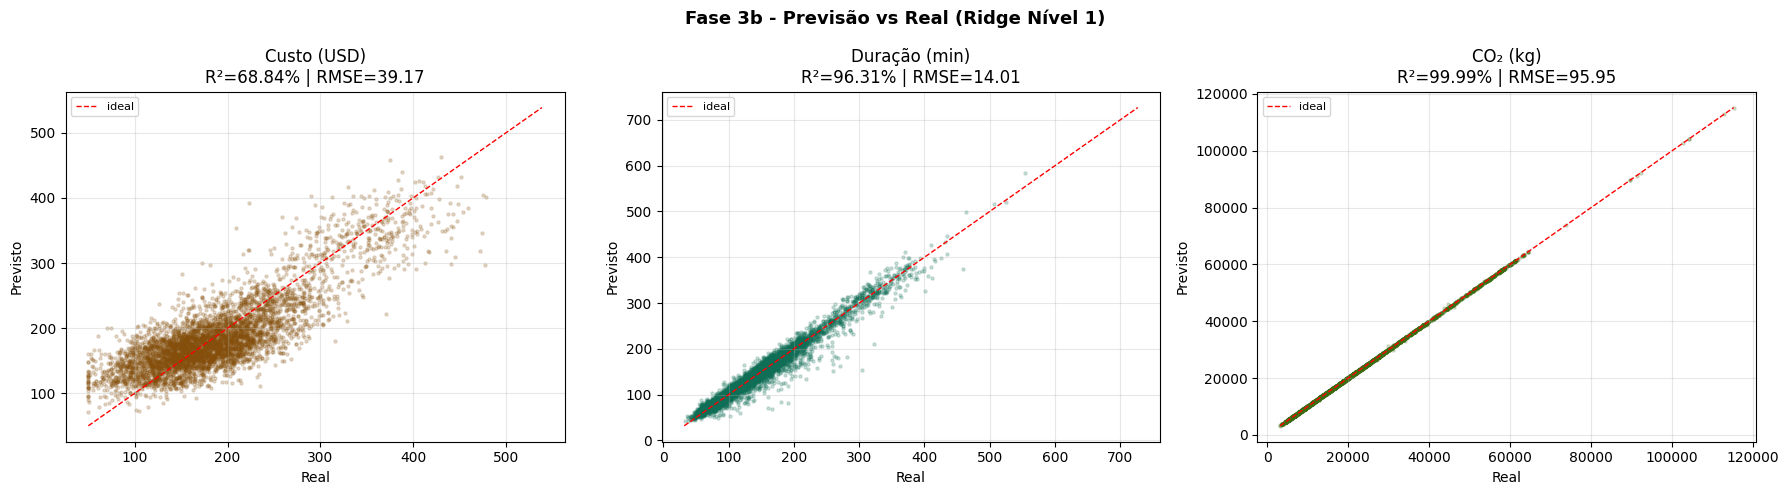

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, y_true, y_pred, color) in zip(axes, [
    ('Custo (USD)',   y_c, pred_cost_final, '#854F0B'),
    ('Duração (min)', y_d, pred_dur_final,  '#0F6E56'),
    ('CO₂ (kg)',      y_e, pred_co2_final,  '#3B6D11'),
]):
    s = np.random.choice(len(y_true), min(5000, len(y_true)), replace=False)
    ax.scatter(y_true[s], y_pred[s], alpha=0.2, s=5, color=color)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1, label='ideal')
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_xlabel('Real'); ax.set_ylabel('Previsto')
    ax.set_title(f'{title}\nR²={r2*100:.2f}% | RMSE={rmse:.2f}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Fase 3b - Previsão vs Real (Ridge Nível 1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fase3b_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

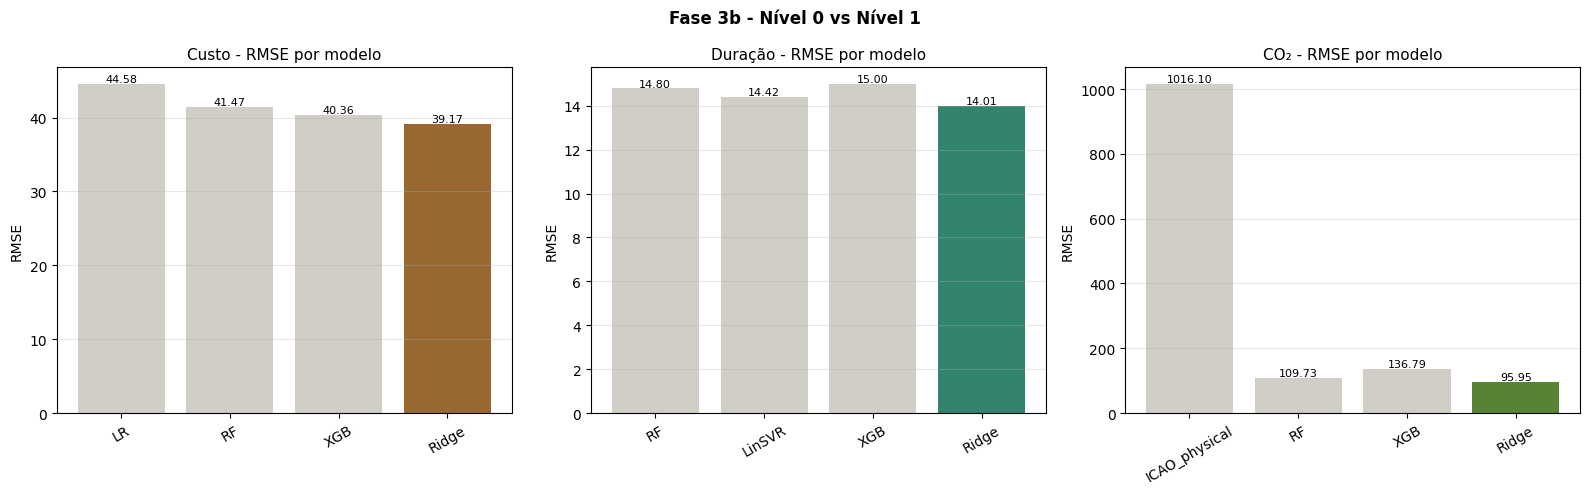

In [15]:
# RMSE por modelo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, results, color) in zip(axes, [
    ('Custo',   results_cost_l0 + [r_cost],  '#854F0B'),
    ('Duração', results_dur_l0  + [r_dur],   '#0F6E56'),
    ('CO₂',     results_co2_l0  + [r_co2],   '#3B6D11'),
]):
    names = [r['model'].replace('_cost','').replace('_dur','').replace('_co2','') for r in results]
    rmses = [r['rmse'] for r in results]
    cols  = [color if 'Ridge' in r['model'] else '#C8C6BE' for r in results]
    bars  = ax.bar(names, rmses, color=cols, alpha=0.85)
    for bar, v in zip(bars, rmses):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005*max(rmses),
                f'{v:.2f}', ha='center', fontsize=8)
    ax.set_title(f'{title} - RMSE por modelo', fontsize=11)
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Fase 3b - Nível 0 vs Nível 1', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fase3b_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Interpretabilidade - SHAP

Background dataset has 172406 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=172406 when initializing the masker.


A calcular SHAP para Custo...


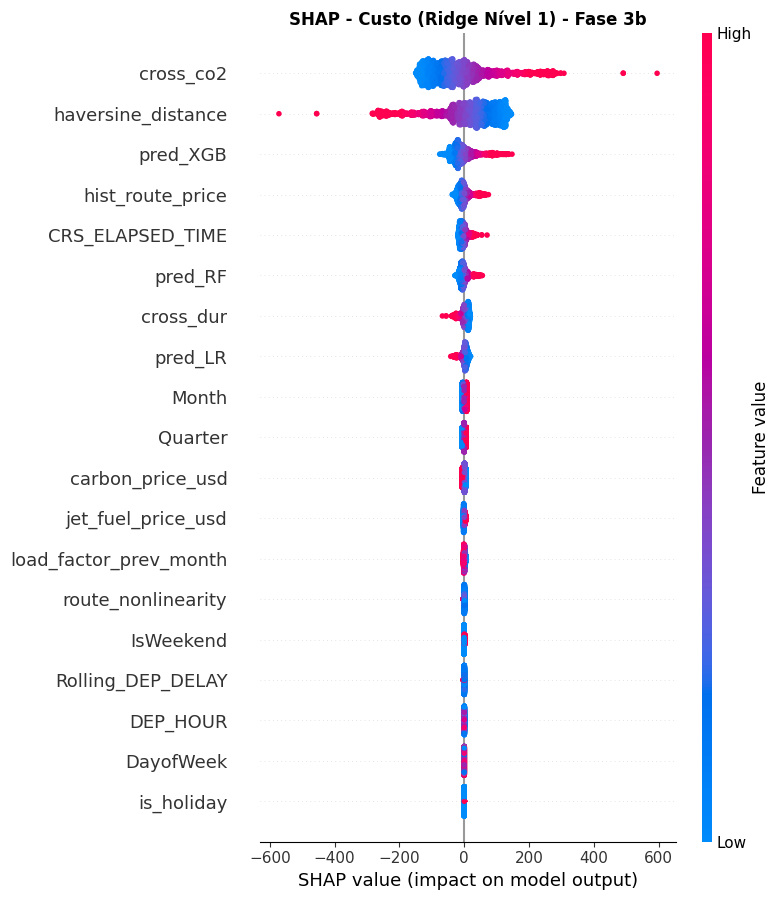

Background dataset has 172406 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=172406 when initializing the masker.


A calcular SHAP para Duração...


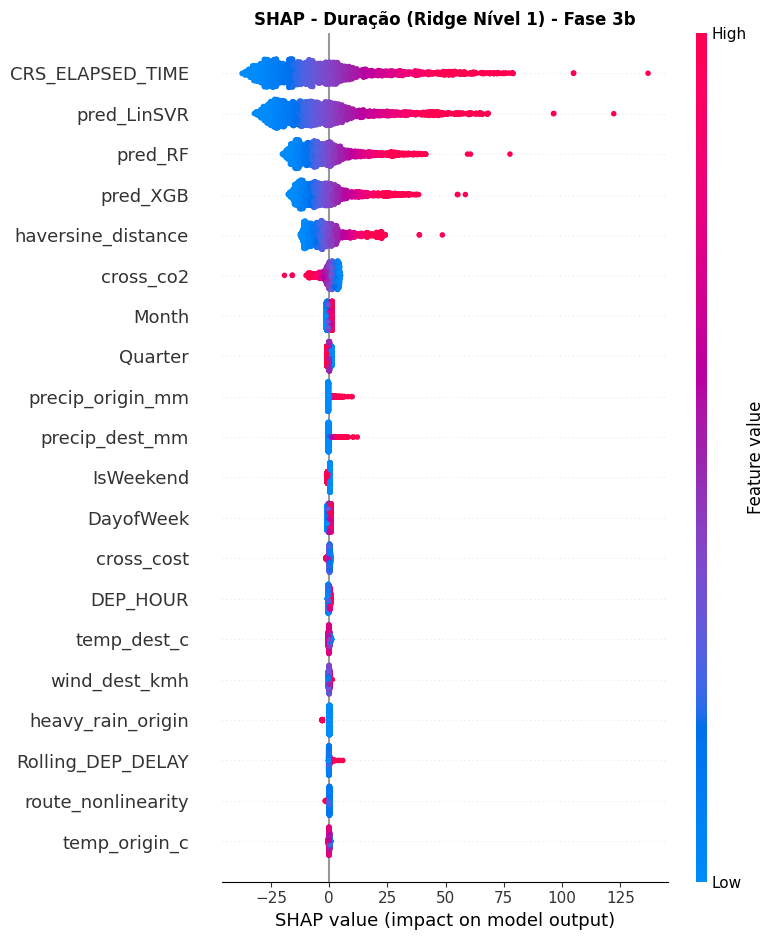

Background dataset has 172406 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=172406 when initializing the masker.


A calcular SHAP para CO₂...


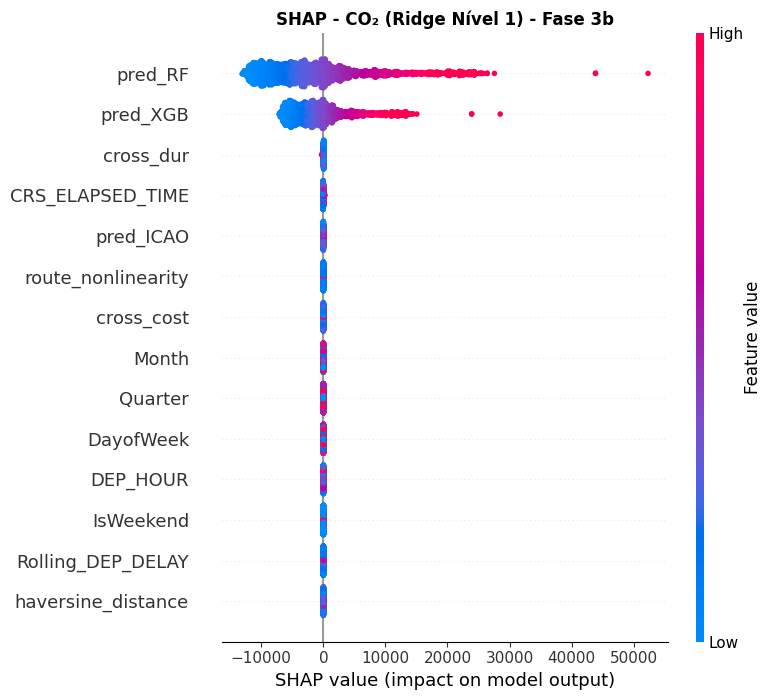

In [16]:
meta_cols = {
    'cost':     ['pred_LR','pred_RF','pred_XGB'] + FEATS_L1_COST + ['cross_dur','cross_co2'],
    'duration': ['pred_RF','pred_LinSVR','pred_XGB'] + FEATS_L1_DUR + ['cross_cost','cross_co2'],
    'co2':      ['pred_ICAO','pred_RF','pred_XGB'] + FEATS_L1_CO2 + ['cross_cost','cross_dur'],
}

sample_idx = np.random.choice(len(X_meta_cost), min(3000, len(X_meta_cost)), replace=False)

for ridge, X_meta, name, title in [
    (ridge_cost, X_meta_cost, 'cost',     'Custo'),
    (ridge_dur,  X_meta_dur,  'duration', 'Duração'),
    (ridge_co2,  X_meta_co2,  'co2',      'CO₂'),
]:
    print(f'A calcular SHAP para {title}...')
    explainer = shap.LinearExplainer(ridge, X_meta)
    shap_vals = explainer.shap_values(X_meta[sample_idx])

    fig, ax = plt.subplots(figsize=(11, 8))
    shap.summary_plot(shap_vals, X_meta[sample_idx],
                      feature_names=meta_cols[name],
                      plot_type='dot', show=False)
    plt.title(f'SHAP - {title} (Ridge Nível 1) - Fase 3b', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'fig_fase3b_shap_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 12. Camada de Cenários

Na Fase 3b os cenários variam features externas reais.

| Cenário | jet_fuel | carbon_price | temperatura, chuva e vento extremos |
|---|---|---|---|
| Otimista | p10 (baixo) | Q1 2023 ($27.85) | 0 |
| Balanceado | média | média | média |
| Pessimista | p90 (alto) | Q4 2023 ($38.73) | 1 |

In [17]:
p10_fuel = df['jet_fuel_price_usd'].quantile(0.10)
mean_fuel = df['jet_fuel_price_usd'].mean()
p90_fuel  = df['jet_fuel_price_usd'].quantile(0.90)

SCENARIOS = {
    'Otimista': {
        'jet_fuel_price_usd': p10_fuel,
        'carbon_price_usd':   27.85,
        'extreme_temp_origin': 0, 'extreme_temp_dest': 0,
        'heavy_rain_origin':   0, 'heavy_rain_dest':   0,
        'strong_wind_origin':  0, 'strong_wind_dest':  0,
    },
    'Balanceado': {
        'jet_fuel_price_usd': mean_fuel,
        'carbon_price_usd':   df['carbon_price_usd'].mean(),
    },
    'Pessimista': {
        'jet_fuel_price_usd': p90_fuel,
        'carbon_price_usd':   38.73,
        'extreme_temp_origin': 1, 'extreme_temp_dest': 1,
        'heavy_rain_origin':   1, 'heavy_rain_dest':   1,
        'strong_wind_origin':  1, 'strong_wind_dest':  1,
    },
}

print('Cenários Fase 3b:')
for nome, vals in SCENARIOS.items():
    print(f'  {nome:<12}: jet_fuel=${vals["jet_fuel_price_usd"]:.3f} | '
          f'carbon=${vals["carbon_price_usd"]:.2f}')

Cenários Fase 3b:
  Otimista    : jet_fuel=$2.184 | carbon=$27.85
  Balanceado  : jet_fuel=$2.655 | carbon=$30.69
  Pessimista  : jet_fuel=$3.191 | carbon=$38.73


In [18]:
results_scenarios = {}

for nome, vals in SCENARIOS.items():
    X_l1_cost_sc_cen = X_l1_cost_sc.copy()
    X_l1_dur_sc_cen  = X_l1_dur_sc.copy()
    X_l1_co2_sc_cen  = X_l1_co2_sc.copy()

    for feat, val in vals.items():
        if feat in FEATS_L1_COST:
            idx = FEATS_L1_COST.index(feat)
            X_l1_cost_sc_cen[:, idx] = (val - sc_l1_cost.mean_[idx]) / sc_l1_cost.scale_[idx]
        if feat in FEATS_L1_DUR:
            idx = FEATS_L1_DUR.index(feat)
            X_l1_dur_sc_cen[:, idx] = (val - sc_l1_dur.mean_[idx]) / sc_l1_dur.scale_[idx]
        if feat in FEATS_L1_CO2:
            idx = FEATS_L1_CO2.index(feat)
            X_l1_co2_sc_cen[:, idx] = (val - sc_l1_co2.mean_[idx]) / sc_l1_co2.scale_[idx]

    X_mc = np.hstack([oof_c, X_l1_cost_sc_cen, mean_dur, mean_co2])
    X_md = np.hstack([oof_d, X_l1_dur_sc_cen,  mean_cost, mean_co2])
    X_me = np.hstack([oof_e, X_l1_co2_sc_cen,  mean_cost, mean_dur])

    pc  = ridge_cost.predict(X_mc)
    pd_ = ridge_dur.predict(X_md)
    pe  = ridge_co2.predict(X_me)

    results_scenarios[nome] = {'cost': pc, 'dur': pd_, 'co2': pe}
    print(f'{nome:<12}: custo={pc.mean():.1f} USD | '
          f'dur={pd_.mean():.1f} min | CO₂={pe.mean():.0f} kg')

Otimista    : custo=190.3 USD | dur=147.1 min | CO₂=21514 kg
Balanceado  : custo=189.5 USD | dur=146.9 min | CO₂=21514 kg
Pessimista  : custo=182.4 USD | dur=137.8 min | CO₂=21514 kg


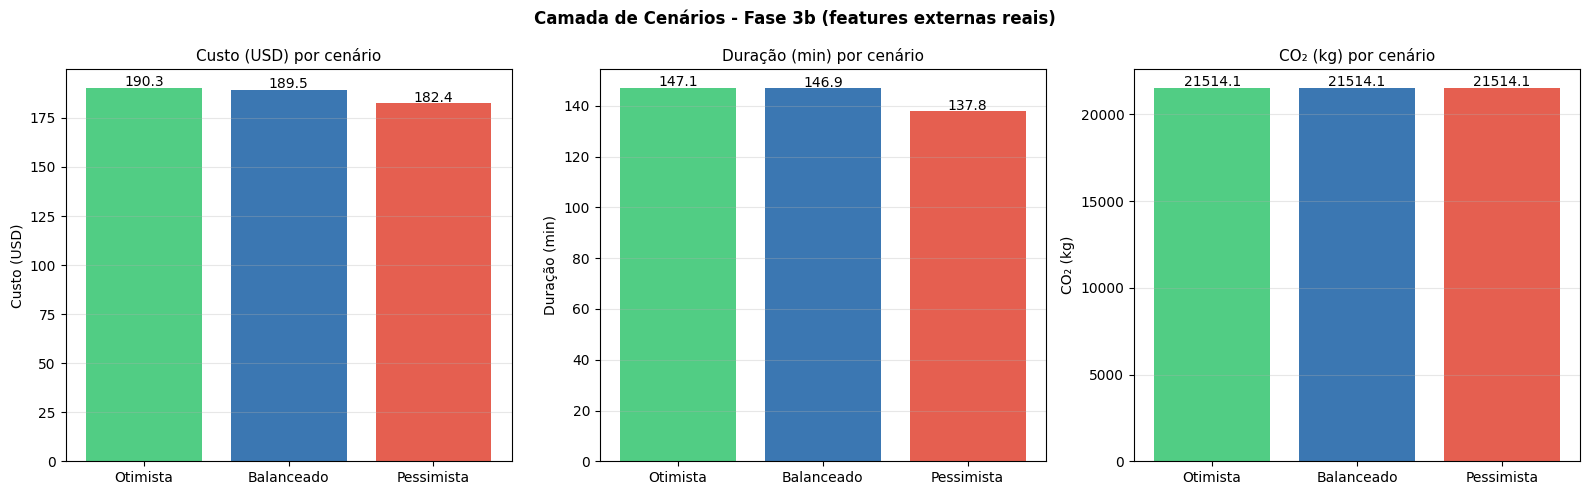

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cen_colors = {'Otimista':'#32c56f','Balanceado':'#185FA5','Pessimista':'#e14331'}
cen_names  = list(SCENARIOS.keys())

for ax, (key, label) in zip(axes, [('cost','Custo (USD)'),('dur','Duração (min)'),('co2','CO₂ (kg)')]):
    vals   = [results_scenarios[c][key].mean() for c in cen_names]
    colors = [cen_colors[c] for c in cen_names]
    bars   = ax.bar(cen_names, vals, color=colors, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005*max(vals),
                f'{v:.1f}', ha='center', fontsize=10)
    ax.set_title(f'{label} por cenário', fontsize=11)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Camada de Cenários - Fase 3b (features externas reais)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fase3b_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Perfis de Decisão

In [20]:
PROFILES = {
    'Económico':   {'w_cost':0.70,'w_time':0.20,'w_co2':0.10},
    'Rápido':      {'w_cost':0.10,'w_time':0.80,'w_co2':0.10},
    'Sustentável': {'w_cost':0.10,'w_time':0.10,'w_co2':0.80},
    'Equilibrado': {'w_cost':0.33,'w_time':0.34,'w_co2':0.33},
}

def normalise(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)

score_rows = []
for cen, preds in results_scenarios.items():
    c_n = normalise(preds['cost'])
    d_n = normalise(preds['dur'])
    e_n = normalise(preds['co2'])
    for profile, w in PROFILES.items():
        score = w['w_cost']*c_n + w['w_time']*d_n + w['w_co2']*e_n
        score_rows.append({
            'cenario': cen, 'perfil': profile,
            'score_medio': score.mean(),
            'custo_medio': preds['cost'].mean(),
            'dur_media':   preds['dur'].mean(),
            'co2_medio':   preds['co2'].mean(),
        })

df_scores = pd.DataFrame(score_rows)
print('Scores por perfil e cenário:')
print(df_scores.pivot(index='perfil', columns='cenario', values='score_medio').round(4).to_string())

Scores por perfil e cenário:
cenario      Balanceado  Otimista  Pessimista
perfil                                       
Económico        0.2646    0.2646      0.2646
Equilibrado      0.2121    0.2122      0.2122
Rápido           0.1808    0.1810      0.1810
Sustentável      0.1783    0.1783      0.1783


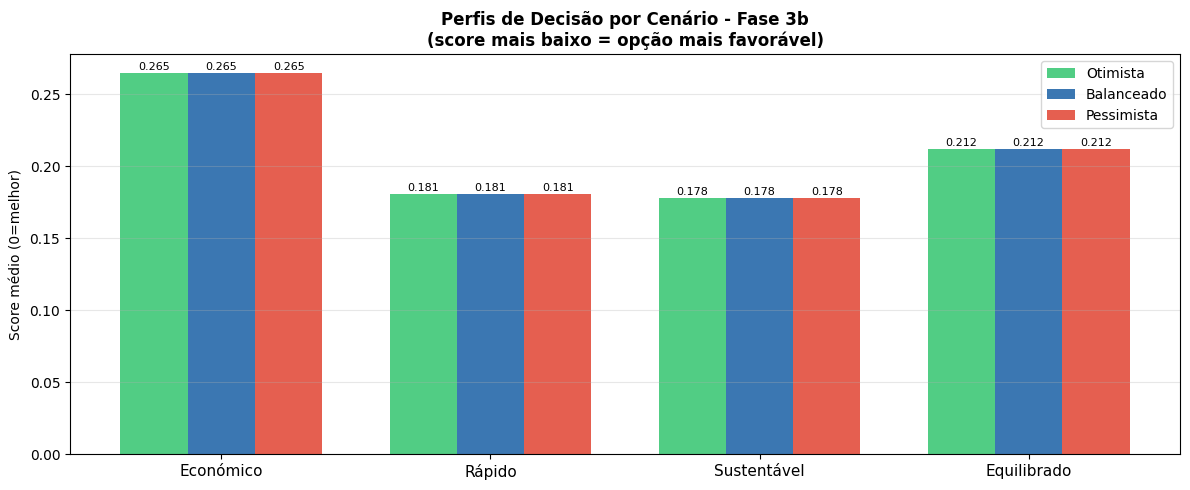

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
profile_names = list(PROFILES.keys())
x = np.arange(len(profile_names))
width = 0.25

for i, (cen, color) in enumerate(cen_colors.items()):
    scores = [df_scores[(df_scores['cenario']==cen) &
                        (df_scores['perfil']==p)]['score_medio'].values[0]
              for p in profile_names]
    bars = ax.bar(x + i*width, scores, width, label=cen, color=color, alpha=0.85)
    for bar, v in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002, f'{v:.3f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(profile_names, fontsize=11)
ax.set_ylabel('Score médio (0=melhor)')
ax.set_title('Perfis de Decisão por Cenário - Fase 3b\n(score mais baixo = opção mais favorável)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_fase3b_decision_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Comparação Fase 3a vs Fase 3b

In [22]:
# Resultados Fase 3a (copiar do NB05)
# Atualizar com os valores reais da Fase 3a, caso necessário
resultados_3a = {
    'custo_rmse':   36.32, 'custo_r2':   73.20,
    'dur_rmse':     14.18, 'dur_r2':     96.22,
    'co2_rmse':     96.40, 'co2_r2':     99.995,
}

resultados_3b = {
    'custo_rmse': r_cost['rmse'], 'custo_r2': r_cost['r2'],
    'dur_rmse':   r_dur['rmse'],  'dur_r2':   r_dur['r2'],
    'co2_rmse':   r_co2['rmse'],  'co2_r2':   r_co2['r2'],
}


print('Comparação Fase 3a vs Fase 3b (Ridge Nível 1)')
print(f'  {"":<20} {"Fase 3a":>12} {"Fase 3b":>12} {"delta RMSE":>10}')

for label, key_rmse, key_r2 in [
    ('Custo (USD)',   'custo_rmse', 'custo_r2'),
    ('Duração (min)', 'dur_rmse',   'dur_r2'),
    ('CO₂ (kg)',      'co2_rmse',   'co2_r2'),
]:
    r3a = resultados_3a[key_rmse]
    r3b = resultados_3b[key_rmse]
    delta = r3b - r3a
    delta_str = f'{delta:+.3f} ({"melhoria" if delta < 0 else "pior"})'
    print(f'  {label:<20} RMSE={r3a:>7.2f}  RMSE={r3b:>7.2f}  {delta_str}')
    print(f'  {"":<20} R²={resultados_3a[key_r2]:>8.2f}%  R²={resultados_3b[key_r2]:>8.2f}%')
    print()

Comparação Fase 3a vs Fase 3b (Ridge Nível 1)
                            Fase 3a      Fase 3b delta RMSE
  Custo (USD)          RMSE=  36.32  RMSE=  39.17  +2.850 (pior)
                       R²=   73.20%  R²=   68.84%

  Duração (min)        RMSE=  14.18  RMSE=  14.01  -0.171 (melhoria)
                       R²=   96.22%  R²=   96.31%

  CO₂ (kg)             RMSE=  96.40  RMSE=  95.95  -0.451 (melhoria)
                       R²=  100.00%  R²=   99.99%



## 15. Resumo

In [23]:
print('Resumo - Notebook Fase 3b:')

print(f'Dataset: {len(df_model):,} voos · 8 meses (Jan–Ago 2023)')
print(f'Features: {len(available)} ({len(FEATURES_EXT)} externas)')
print(f'Validação: walk-forward 5 folds temporais')
print()

print('Features externas selecionadas por target:')
for t, label in [(TARGET_COST,'Custo'),(TARGET_DURATION,'Duração'),(TARGET_CO2,'CO₂')]:
    ext_sel = [f for f in feature_sets[t] if f in FEATURES_EXT]
    print(f'  {label}: {ext_sel}')
print()

print('Resultados finais (Ridge Nível 1):')
for r, label in [(r_cost,'Custo (USD)  '),(r_dur,'Duração (min)'),(r_co2,'CO₂ (kg)     ')]:
    print(f'  {label}  RMSE={r["rmse"]:.3f} | R²={r["r2"]:.3f}%')
print()

print('Cenários Fase 3b (variação real com features externas):')
for cen, preds in results_scenarios.items():
    print(f'  {cen:<12}: ${preds["cost"].mean():.0f} USD | '
          f'{preds["dur"].mean():.0f} min | {preds["co2"].mean():.0f} kg CO₂')

Resumo - Notebook Fase 3b:
Dataset: 195,950 voos · 8 meses (Jan–Ago 2023)
Features: 36 (17 externas)
Validação: walk-forward 5 folds temporais

Features externas selecionadas por target:
  Custo: ['load_factor_prev_month', 'hist_route_price']
  Duração: ['load_factor_prev_month', 'temp_origin_c', 'temp_dest_c', 'precip_origin_mm', 'precip_dest_mm', 'wind_origin_kmh', 'wind_dest_kmh']
  CO₂: []

Resultados finais (Ridge Nível 1):
  Custo (USD)    RMSE=39.170 | R²=68.837%
  Duração (min)  RMSE=14.009 | R²=96.312%
  CO₂ (kg)       RMSE=95.949 | R²=99.995%

Cenários Fase 3b (variação real com features externas):
  Otimista    : $190 USD | 147 min | 21514 kg CO₂
  Balanceado  : $189 USD | 147 min | 21514 kg CO₂
  Pessimista  : $182 USD | 138 min | 21514 kg CO₂
